In [1]:
import sys
import os 
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.analysis.sensitivity import SensitivityAnalyzer
from omegaconf import OmegaConf

In [2]:
parameter_ranges = OmegaConf.load('../param_config.yaml')
dependent_parameter_names = ['Pc_des']
dependent_parameters = [{'parameter_name': 'Pc_des', 'function': lambda Pa_des : Pa_des - 20000, 'dependent_param': 'Pa_des'}]

SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=1024 , calculate_second_order=True)

SA.generate_samples()
SA.rescale_samples()
samples = SA.apply_dependent_parameters(dependent_parameters)
samples

,Tfc,Pa_des,Sc,Phi_c_des,epsilon_gdl,tau,epsilon_mc,epsilon_c,e,Re,i0_c_ref,kappa_co,kappa_c,Pc_des
0,345.931298,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
1,350.820492,268431.866782,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
2,345.931298,201919.596742,2.632068,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,181919.596742
3,345.931298,268431.866782,1.789658,0.132128,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
4,345.931298,268431.866782,2.632068,0.145910,0.624495,3.51943,0.324434,0.240591,5,0.000001,42.263443,31.825707,0.952710,248431.866782
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28667,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000005,56.300426,20.085051,2.250420,132452.823874
28668,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,20.832063,20.085051,2.250420,132452.823874
28669,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,56.300426,31.383792,2.250420,132452.823874
28670,340.898636,152452.823874,1.307282,0.283673,0.728948,1.93546,0.292262,0.227824,3,0.000002,56.300426,20.085051,0.862373,132452.823874


In [3]:
dejvis = samples[0:15000]
camila = samples[15000:21836]
nathaly = samples[21836:]

In [3]:
import pandas as pd
import glob
# Adjust the path to point to external/AlphaPEM
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.sampling.sampler import get_polarisation_curve_samples, build_fixed_parameters

# Locate all pickle files in the folder
file_paths = glob.glob('../sampling_test/*.pkl')

# Read each pickle file into a DataFrame and collect them
df_list = [pd.read_pickle(path) for path in file_paths]

# Concatenate all DataFrames vertically into one
combined_df = pd.concat(df_list, ignore_index=True)

# Print the overall shape
print(f"Combined DataFrame shape: {combined_df.shape}")

data = combined_df.dropna()
print(f"Data shape after dropping NaN: {data.shape}")

Combined DataFrame shape: (12000, 48)
Data shape after dropping NaN: (11994, 48)


In [70]:
# Expand Ucell
Ucell_wide = combined_df['Ucell'].apply(pd.Series)
Ucell_wide.columns = [f'Ucell_{i}' for i in Ucell_wide.columns]

# Expand ifc
ifc_wide = combined_df['ifc'].apply(pd.Series)
ifc_wide.columns = [f'ifc_{i}' for i in ifc_wide.columns]

# Combine with original DataFrame (excluding old list columns)
data = pd.concat([combined_df.drop(['Ucell', 'ifc'], axis=1), Ucell_wide, ifc_wide], axis=1)

# Identify Ucell and ifc columns
ucell_cols = [col for col in data.columns if col.startswith('Ucell_')]
ifc_cols = [col for col in data.columns if col.startswith('ifc_')]

# Combine Ucell columns into lists per row
data['Ucell'] = data[ucell_cols].values.tolist()

omegaconf_dict = OmegaConf.load('../param_config.yaml')
columns = list(omegaconf_dict.keys())
columns.extend(ifc_wide.columns.tolist())
columns.extend(Ucell_wide.columns.tolist())
data[columns].to_csv('../sampling_test/combined_data.csv', index=False)

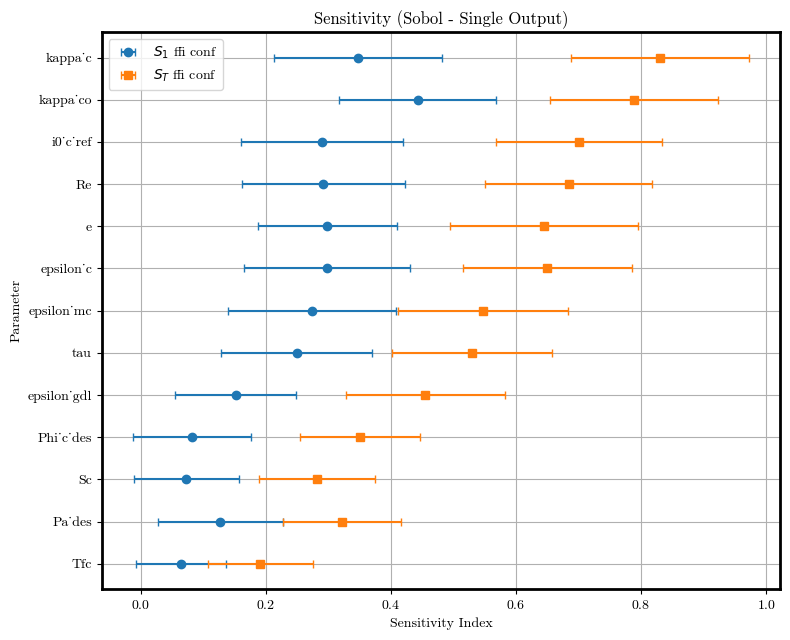

In [27]:
SA = SensitivityAnalyzer(parameter_ranges, dependent_parameter_names=None, method='sobol', seed=42, N=256 , calculate_second_order=True)
samples = SA.generate_samples()
cols = list(samples.columns)
cols.append('Ucell')
cols.append('ifc')
results = SA.run_analysis(data[cols][:len(samples)], "fPCA")
SA.plot_grid(results)

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_rankings_for_Ns(parameter_ranges, data, Ns, **SA_kwargs):
    rankings = []
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=True,
            **SA_kwargs
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method="fPCA")

        # grab ST for output_index 0
        st = next(r['ST'] for r in results if r['output_index'] == 0)
        if param_names is None:
            param_names = results[0]['param']

        order = np.argsort(-st)     # descending
        ranks = np.empty_like(order)
        ranks[order] = np.arange(1, len(st)+1)
        rankings.append(dict(zip(param_names, ranks)))

    return pd.DataFrame(rankings, index=Ns)

import warnings
# 1) silence that specific FutureWarning
warnings.filterwarnings(
    "ignore",
    message="unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated"
)
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
    message="The balance properties of Sobol' points require n to be a power of 2"
)

# 1) build the full N list
Ns = list(range(2, 257, 4))   # [2, 6, 10, …, 254]

# 2) compute rank_df however you have it
rank_df = compute_rankings_for_Ns(parameter_ranges, data, Ns)



/var/folders/nh/g7l50kcx5r9g8d05q_6qbr000000gn/T/ipykernel_28536/1140108186.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)


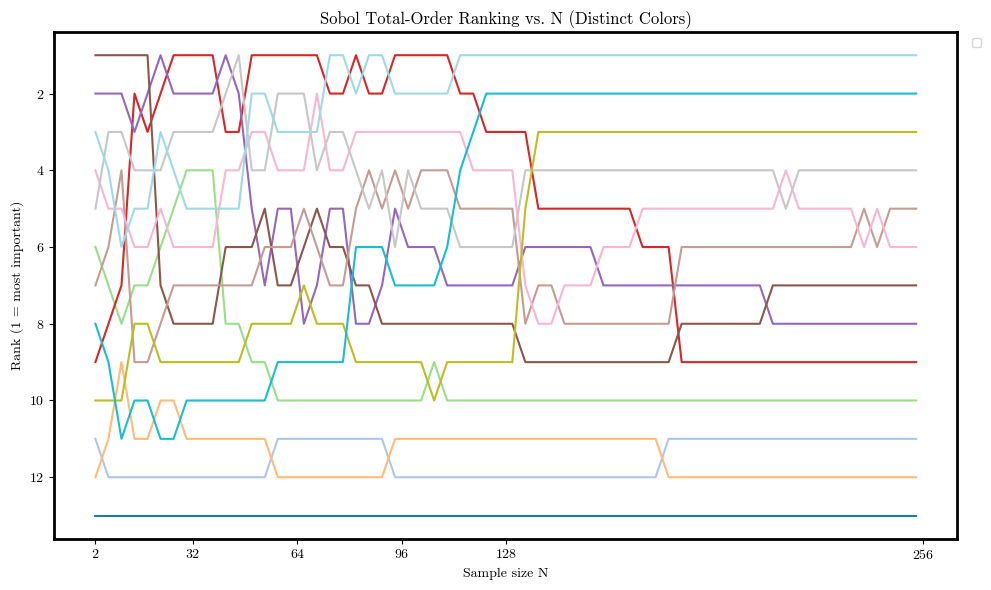

In [29]:

# 3) pick a colormap with at least as many colors as you have parameters
n_params = len(rank_df.columns)
cmap = plt.get_cmap('tab20', n_params)  # tab20 provides up to 20 distinct colors

plt.figure(figsize=(10, 6))
for idx, param in enumerate(rank_df.columns):
    y = rank_df[param].loc[Ns]
    plt.plot(Ns, y, color=cmap(idx))


plt.gca().invert_yaxis()
plt.xticks([2, 32, 64, 96, 128, 256])
plt.xlabel("Sample size N")
plt.ylabel("Rank (1 = most important)")
plt.title("Sobol Total-Order Ranking vs. N (Distinct Colors)")
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize="small", ncol=1)
plt.tight_layout()
plt.show()

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def compute_indices_for_Ns(parameter_ranges, data, Ns, **SA_kwargs):
    """
    For each sample size N in Ns, run Sobol+fPCA analysis,
    extract total-order indices ST for the first output,
    and return a DataFrame of ST values (shape len(Ns) × n_params).
    """
    indices_list = []
    param_names = None

    for N in Ns:
        SA = SensitivityAnalyzer(
            parameter_ranges,
            dependent_parameter_names=None,
            method='sobol',
            seed=42,
            N=N,
            calculate_second_order=True,
            **SA_kwargs
        )
        samples = SA.generate_samples()
        subdata = data.iloc[:len(samples)]
        results = SA.run_analysis(subdata, aggregation_method="fPCA")

        # extract S_T for output_index == 0
        st = next(r['ST'] for r in results if r['output_index'] == 0)
        if param_names is None:
            param_names = results[0]['param']

        indices_list.append(dict(zip(param_names, st)))

    return pd.DataFrame(indices_list, index=Ns)

# 1) define N sweep
Ns = list(range(2, 257, 4))  # [2, 3, …, 128]
# 2) collect ST values
st_df = compute_indices_for_Ns(parameter_ranges, data, Ns)


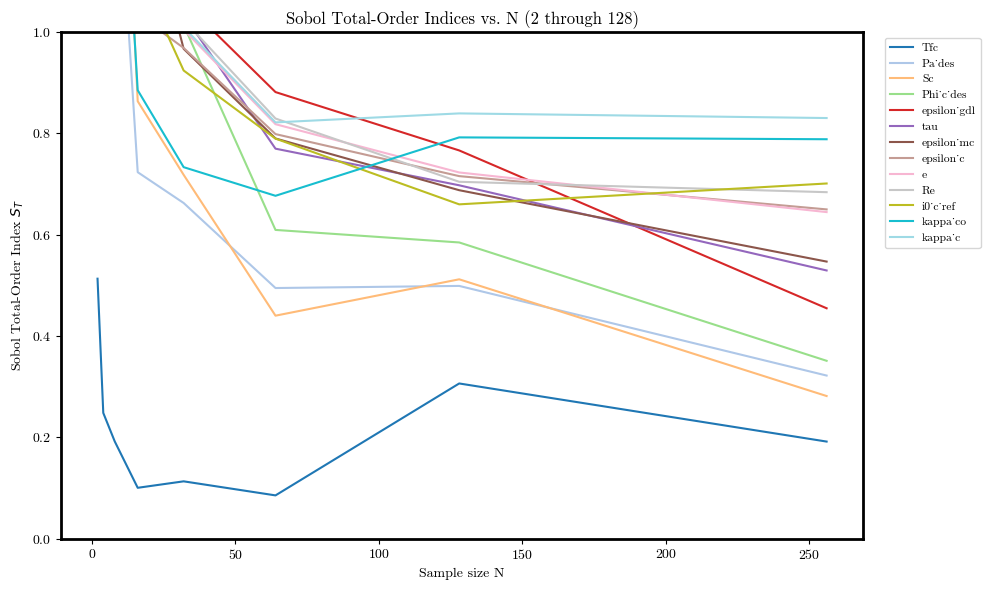

In [41]:

# 3) plot
cmap = plt.get_cmap('tab20', len(st_df.columns))

plt.figure(figsize=(10, 6))
for idx, param in enumerate(st_df.columns):
    plt.plot(
        st_df.index,
        st_df[param],
        label=param,
        color=cmap(idx)
    )

plt.xlabel("Sample size N")
plt.ylabel("Sobol Total-Order Index $S_T$")
plt.title("Sobol Total-Order Indices vs. N (2 through 128)")
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize="small")
plt.tight_layout()
plt.show()

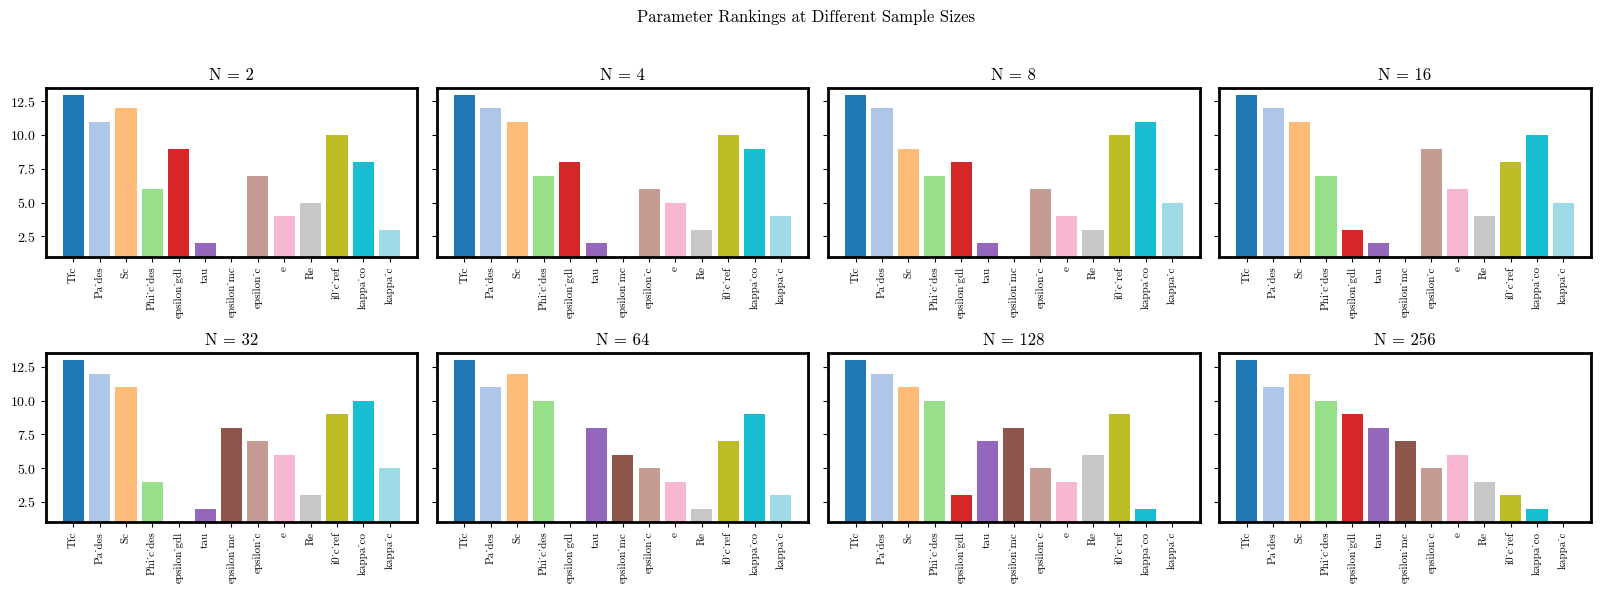

In [32]:
import numpy as np
import matplotlib.pyplot as plt

# Suppose rank_df is your DataFrame of shape (len(Ns) × n_params), indexed by Ns
Ns = [2**i for i in range(1, 9)]         # [2, 4, 8, …, 256]

# 2) compute rank_df however you have it
rank_df = compute_rankings_for_Ns(parameter_ranges, data, Ns)
params = rank_df.columns.tolist()
n_params = len(params)

# Decide grid dimensions: e.g. 2 rows × 4 cols for eight plots
n_cols = 4
n_rows = int(np.ceil(len(Ns) / n_cols))

fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(4 * n_cols, 3 * n_rows),
    sharey=True  # keep y-axis scale consistent
)

for ax, N in zip(axes.flat, Ns):
    # Get the ranking vector for this N
    ranks = rank_df.loc[N]

    # Draw a bar plot: x = parameter index, height = rank
    ax.bar(
        np.arange(n_params),
        ranks,
        color=plt.get_cmap('tab20', n_params).colors  # one distinct color per bar
    )
    ax.set_title(f"N = {N}")
    ax.set_xticks(np.arange(n_params))
    ax.set_xticklabels(params, rotation=90, fontsize=8)
    ax.invert_yaxis()             # rank 1 at top
    ax.set_ylim(1, n_params + 0.5)

# Turn off any unused subplots
for idx in range(len(Ns), n_rows * n_cols):
    fig.delaxes(axes.flat[idx])

fig.suptitle("Parameter Rankings at Different Sample Sizes")
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


Font 'default' does not have a glyph for '\u2010' [U+2010], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2010' [U+2010], substituting with a dummy symbol.


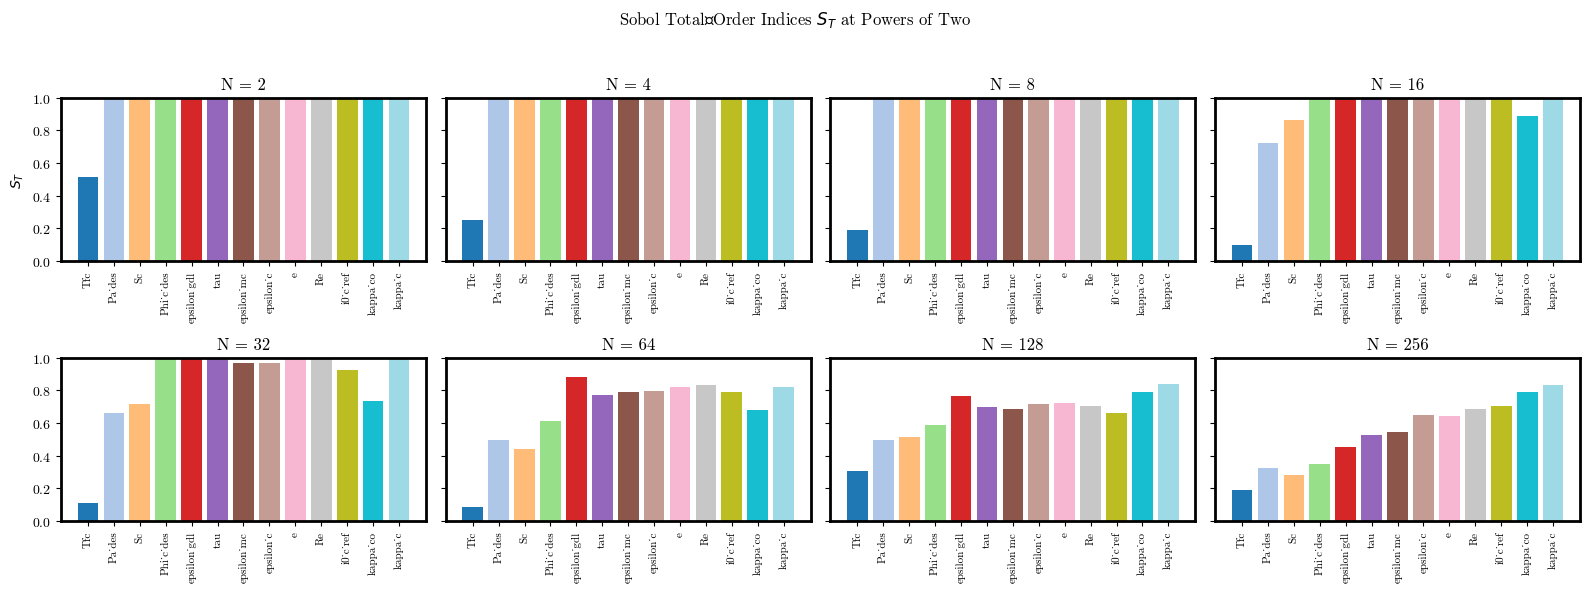

In [40]:
import numpy as np
import matplotlib.pyplot as plt

# 1) powers‐of‐two Ns
Ns = [2**i for i in range(1, 9)]   # [2, 4, 8, 16, 32, 64, 128, 256]
# 2) collect ST values
st_df = compute_indices_for_Ns(parameter_ranges, data, Ns)


params = st_df.columns.tolist()
n_params = len(params)

# 3) grid setup: 2 rows × 4 cols
n_cols = 4
n_rows = int(np.ceil(len(Ns) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3 * n_rows), sharey=True)

# 4) bar‐plot each N’s indices
colors = plt.get_cmap('tab20', n_params).colors
for ax, N in zip(axes.flat, Ns):
    indices = st_df.reindex(Ns).loc[N]  # ensure alignment

    ax.bar(
        np.arange(n_params),
        indices,
        color=colors
    )
    ax.set_title(f"N = {N}")
    ax.set_xticks(np.arange(n_params))
    ax.set_xticklabels(params, rotation=90, fontsize=8)
    ax.set_ylim(0, 1)               # Sobol indices in [0,1]
    ax.set_ylabel("$S_T$" if ax is axes.flat[0] else "")

# 5) clean up any empty subplots
for idx in range(len(Ns), n_rows * n_cols):
    fig.delaxes(axes.flat[idx])

fig.suptitle("Sobol Total‐Order Indices $S_T$ at Powers of Two")
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


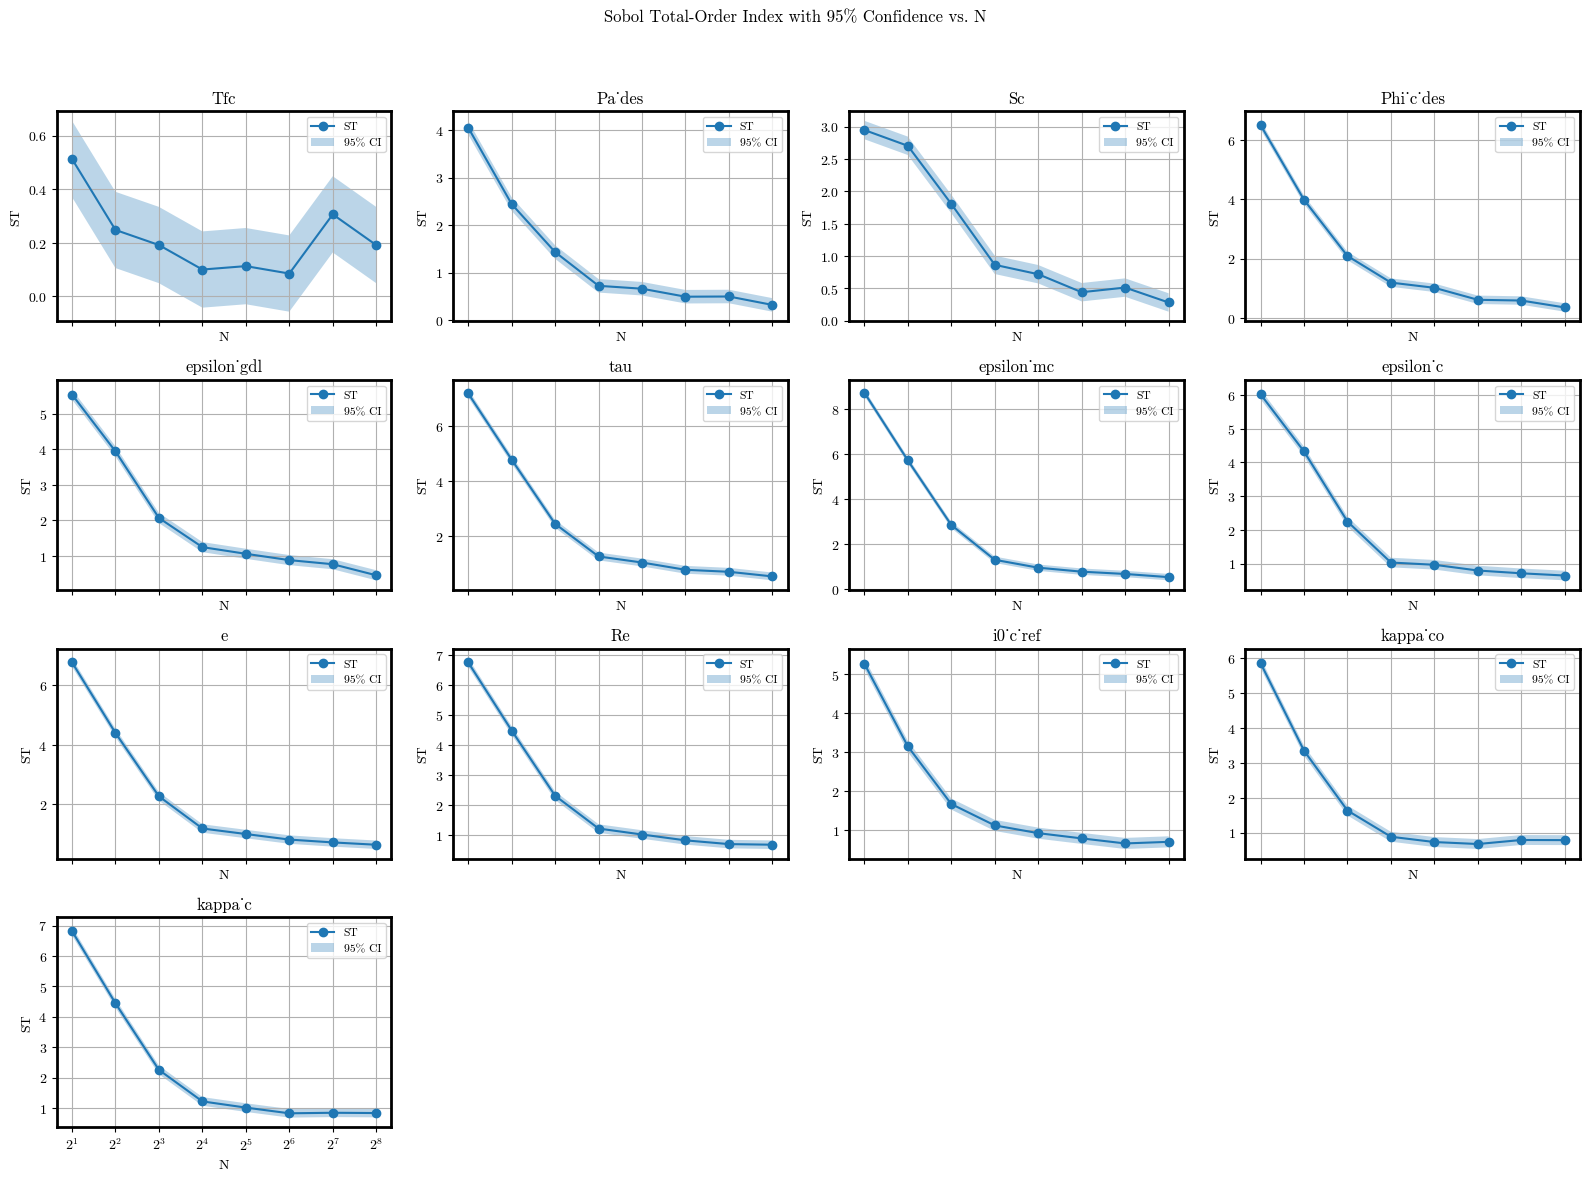

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def plot_index_with_confidence(parameter_ranges, data, Ns, **SA_kwargs):
    """
    For each Sobol parameter, plot its total-order index and confidence interval vs N.
    
    parameter_ranges: dict of ranges passed to SensitivityAnalyzer
    data: DataFrame containing 'Ucell' and 'ifc' columns
    Ns: list of sample sizes (powers of two)
    SA_kwargs: other kwargs for SensitivityAnalyzer (method, seed, calculate_second_order)
    """
    # Storage for each parameter: dict mapping param -> list of (N, ST, ST_conf)
    ci_data = {}
    # Run for each N
    for N in Ns:
        SA = SensitivityAnalyzer(parameter_ranges, method='sobol', seed=42, N=N, calculate_second_order=True)
        samples = SA.generate_samples()
        cols = list(samples.columns) + ['Ucell', 'ifc']
        results = SA.run_analysis(data[cols].iloc[:len(samples)], aggregation_method="fPCA")
        # Extract ST and ST_conf for output 0
        for res in results:
            if res['output_index'] == 0:
                for param, st, conf in zip(res['param'], res['ST'], res['ST_conf']):
                    ci_data.setdefault(param, []).append((N, st, conf))
                break

    # Now plot one subplot per parameter
    n_params = len(ci_data)
    cols = 4
    rows = int(np.ceil(n_params / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3*rows), sharex=True, sharey=False)
    
    for ax, (param, vals) in zip(axes.flat, ci_data.items()):
        vals_sorted = sorted(vals, key=lambda x: x[0])
        Ns_plot, sts, confs = zip(*vals_sorted)
        sts = np.array(sts)
        confs = np.array(confs)
        ax.plot(Ns_plot, sts, marker='o', label='ST')
        ax.fill_between(Ns_plot, sts-conf, sts+conf, alpha=0.3, label='95% CI')
        ax.set_xscale('log', base=2)
        ax.set_title(param)
        ax.set_xlabel("N")
        ax.set_ylabel("ST")
        ax.grid(True)
        ax.legend(loc='upper right', fontsize='small')
    
    # Remove any extra axes
    for idx in range(n_params, rows*cols):
        fig.delaxes(axes.flat[idx])

    fig.suptitle("Sobol Total-Order Index with 95% Confidence vs. N")
    plt.tight_layout(rect=[0,0,1,0.95])
    plt.show()

# Example usage:
Ns = [2,4,8,16,32,64,128, 256]
plot_index_with_confidence(parameter_ranges, data, Ns)
